# Crop Type Classification — Data Exploration & ML model Training

This notebook walks through the full workflow end-to-end using the modules in `src/`:
1. Data loading & inspection
2. Exploratory data analysis
3. Train/val/test split creation
4. Model training (Based on temporal band statistics)
5. Model evaluation

In [10]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_loading import (
    load_config, list_patch_ids, build_dataset_summary, class_pixel_counts,
    load_s2_patch, load_target_patch, load_metadata, create_splits, save_splits, load_splits,
)
from src.preprocessing import compute_temporal_features, clip_and_normalize, sample_pixels
from src.visualization import plot_rgb, plot_label_map, plot_class_distribution, plot_rgb_label_prediction, plot_confusion_matrix

cfg = load_config("../configs/config.yaml")
print("Root folder containing data:", cfg["data"]["root_dir"]) 

Root folder containing data: H:/Job/solafune/Agri-Assignment_01/Agri-Assignment_01/PASTIS_subset


## 1. Data loading and inspection (Task A)

In [ ]:
patch_ids = list_patch_ids(cfg["data"]["root_dir"], cfg["data"]["s2_dir"], cfg["data"]["ann_dir"])
print(f"Found {len(patch_ids)} usable patches")
print("First 10 patch IDs:", patch_ids[:10])

Found 102 usable patches
First 10 patch IDs: ['30003', '30013', '30014', '30023', '30026', '30033', '30048', '30052', '30057', '30059']


In [ ]:
# Inspect a single patch: shapes and dtypes
pid = patch_ids[0]
s2 = load_s2_patch(pid, cfg["data"]["root_dir"], cfg["data"]["s2_dir"])
target = load_target_patch(pid, cfg["data"]["root_dir"], cfg["data"]["ann_dir"])
print("S2 shape (T(time), C(channel), H(height), W(width)):", s2.shape, s2.dtype)
print("Target shape (H, W):", target.shape, target.dtype)
print("Unique classes in this patch:", sorted(set(target.flatten().tolist())))

## 2. Exploratory data analysis (Task B)

(See also `src/eda.py` for the scripted version. For the full run, prefer the CLI: `python src/eda.py --config configs/config.yaml` that writes all figures/tables to `outputs/...`.)

In [ ]:
# Build a dataset summary for each patch 
summary = build_dataset_summary(patch_ids, cfg["data"]["root_dir"], cfg["data"]["s2_dir"], cfg["data"]["ann_dir"])
summary.describe()

[visualization] saved H:\Job\solafune\crop-classification-project\project-root\outputs\figures\Class_distribution_pixel_counts.png


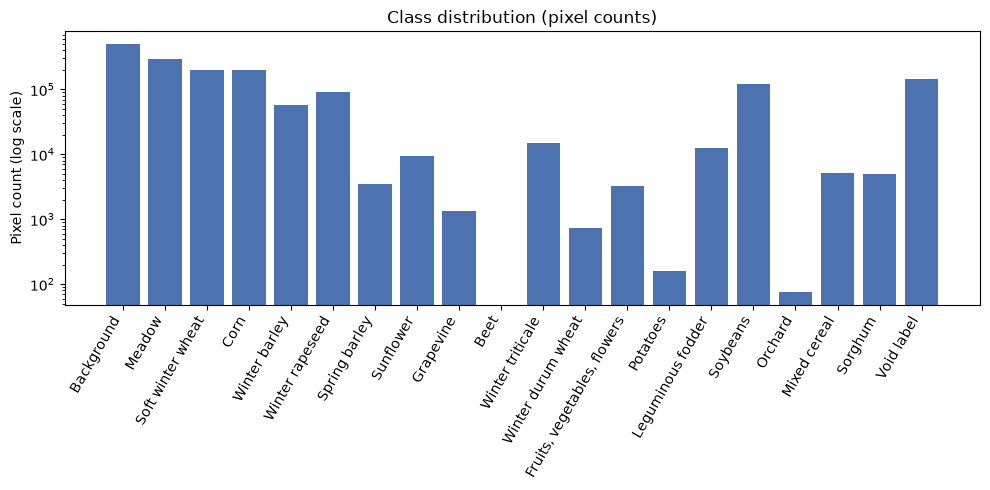

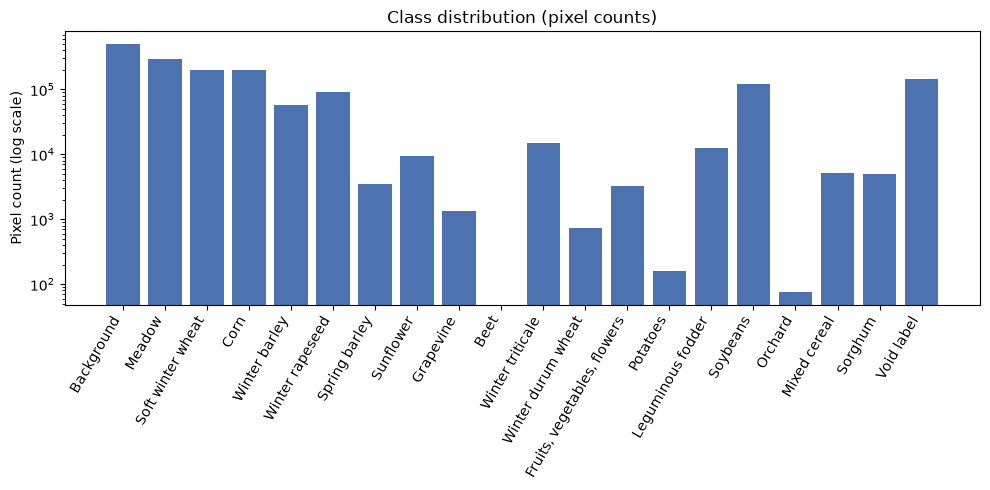

In [ ]:
# Visualize class distribution across the dataset
counts = class_pixel_counts(patch_ids, cfg["data"]["root_dir"], cfg["data"]["ann_dir"], num_classes=cfg["data"]["num_classes"])
plot_class_distribution(counts, cfg["data"]["class_names"], save_path=cfg["output"]["figures_dir"])

[visualization] saved H:\Job\solafune\crop-classification-project\project-root\outputs\figures\Patch_30003_RGB_median_composite.png
[visualization] saved H:\Job\solafune\crop-classification-project\project-root\outputs\figures\Patch_30003_labels.png


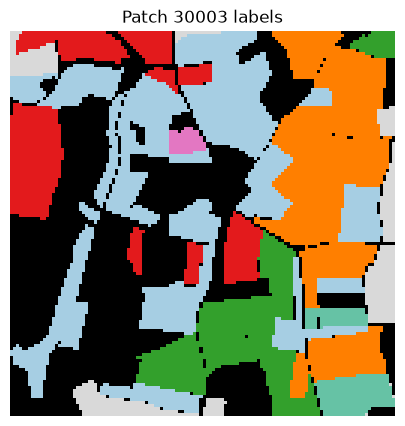

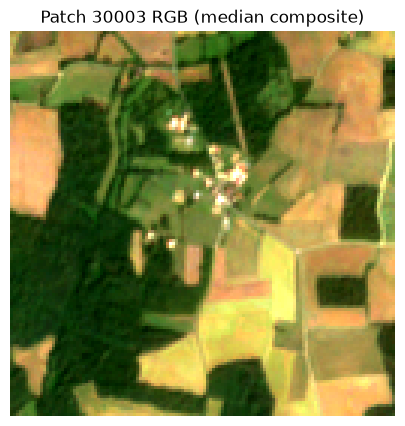

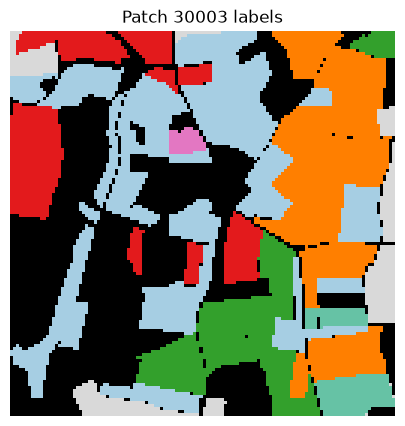

In [ ]:
# Visualize a single patch (RGB map and the corresponding label map)
plot_rgb(s2, title=f"Patch {pid} RGB (median composite)", save_path=cfg["output"]["figures_dir"])
plot_label_map(target, title=f"Patch {pid} labels", num_classes=cfg["data"]["num_classes"], save_path=cfg["output"]["figures_dir"])

In [7]:
# AOI extent, if metadata.geojson is present
metadata = load_metadata(cfg["data"]["root_dir"], cfg["data"]["metadata_file"])
metadata.head() if metadata is not None and hasattr(metadata, "head") else metadata

,Fold,ID_PATCH,N_Parcel,Parcel_Cover,TILE,dates-S2,id,geometry
0,2,30003,82,0.679651,t31tfm,"{'0': 20180920, '1': 20180930, '2': 20181005, ...",30003,"POLYGON ((856217.058 6617142.774, 857495.97 66..."
1,1,30013,46,0.939360,t31tfm,"{'0': 20180920, '1': 20180930, '2': 20181005, ...",30013,"POLYGON ((851104.33 6645279.956, 852383.291 66..."
2,2,30014,61,0.688851,t31tfm,"{'0': 20180920, '1': 20180930, '2': 20181005, ...",30014,"POLYGON ((879236.84 6622256.6, 880515.633 6622..."
3,3,30023,57,0.674748,t31tfm,"{'0': 20180920, '1': 20180930, '2': 20181005, ...",30023,"POLYGON ((875400.317 6620978.106, 876679.13 66..."
4,3,30026,48,0.606728,t31tfm,"{'0': 20180920, '1': 20180930, '2': 20181005, ...",30026,"POLYGON ((848545.818 6641443.436, 849824.786 6..."


## 3. Train / val / test split (Task C)

In [8]:
splits = create_splits(patch_ids, cfg["split"]["train_ratio"], cfg["split"]["val_ratio"],
                        cfg["split"]["test_ratio"], cfg["split"]["seed"])
save_splits(splits, cfg["split"]["splits_dir"])

[data_loading] Saved splits to H:\Job\solafune\crop-classification-project\project-root\outputs\splits: {'train': 71, 'val': 15, 'test': 16}


## 4. Model training (Task D)

For a from-notebook demo we call the same `build_training_set` and  `create_model` logic as `src/train.py`. For the full run, prefer the CLI: `python -m src.train --config configs/config.yaml` (progress bar, saves model + stats to `outputs/models/`).

In [ ]:
from src.train import (build_training_set, create_model)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

train_ids = splits["train"]
X, y, norm_stats = build_training_set(train_ids, cfg)
print(X.shape, y.shape)

clf = create_model(cfg["model"])

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

clf.fit(X, y_encoded)
print("train accuracy:", clf.score(X, y_encoded))

## 5. Evaluation (Task E)

Prefer the CLI for the full run (saves metrics JSON + confusion matrix + per-patch predictions): `python -m src.evaluate --config configs/config.yaml --splits val test`

In [ ]:
from src.evaluate import evaluate_split

val_metrics = evaluate_split("val", splits["val"], clf, norm_stats, cfg, label_encoder)
val_metrics["overall_accuracy"], val_metrics["mean_iou"]

## Output visualisation

Qualitative RGB | ground truth | prediction panels and the confusion matrix are already saved to `outputs/figures/` by `evaluate_split` above.